In [8]:
import sys
import uproot
import awkward as ak
import numpy as np
from coffea import nanoevents
from coffea import lumi_tools
import vector
from rich import print
from rich.progress import track
import math
import matplotlib.pyplot as plt
import matplotlib
import mplhep as hep
import hist
from hist import Hist

In [9]:
sys.path.insert(0, "../../workflows/")

In [10]:
sys.path.insert(0, "../../")

In [11]:
matplotlib.rcParams.update({"figure.max_open_warning": 0})
hep.style.use(hep.style.CMS)

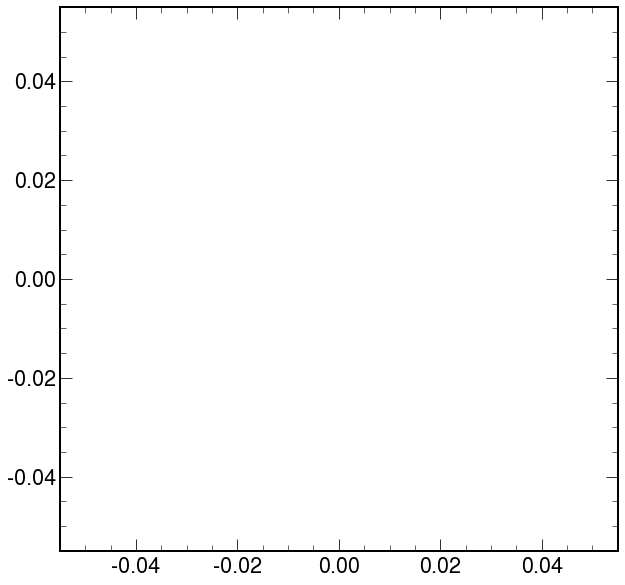

In [12]:
plt.plot()
hep.style.use(hep.style.CMS)

In [13]:
np.set_printoptions(precision=2)

In [14]:
vector.register_awkward()

In [15]:
def apply_golden_JSON(events, era):
    if era == "2016" or era == "2016APV":
        LumiJSON = lumi_tools.LumiMask(
            "../../data/GoldenJSON/Cert_271036-284044_13TeV_Legacy2016_Collisions16_JSON.txt"
        )
    elif era == "2017":
        LumiJSON = lumi_tools.LumiMask(
            "../../data/GoldenJSON/Cert_294927-306462_13TeV_UL2017_Collisions17_GoldenJSON.txt"
        )
    elif era == "2018":
        LumiJSON = lumi_tools.LumiMask(
            "../../data/GoldenJSON/Cert_314472-325175_13TeV_Legacy2018_Collisions18_JSON.txt"
        )
    elif era == "2022" or era == "2022EE":
        LumiJSON = lumi_tools.LumiMask(
            "../../data/GoldenJSON/Cert_Collisions2022_355100_362760_Golden.json"
        )
    elif era == "2023" or era == "2023BPix":
        LumiJSON = lumi_tools.LumiMask(
            "../../data/GoldenJSON/Cert_Collisions2023_366442_370790_Golden.json"
        )
    else:
        print("No era is defined. Please specify the year")

    events = events[LumiJSON(events.run, events.luminosityBlock)]

    return events

In [16]:
def clean_muons(muons):
    cleaning = (
        (muons.pt > 3)
        & (abs(muons.eta) < 2.4)
        & muons.mediumId
        & (abs(muons.dz) < 0.1)
        & (abs(muons.dxy) < 0.1)
        & (abs(muons.ip3d) < 0.1)
    )
    muons = muons[cleaning]
    return muons

In [17]:
data_2016B_v1_APV = "Run2016B/DoubleMuon/NANOAOD/ver1_HIPM_UL2016_MiniAODv2_NanoAODv9-v2/2530000/99DA5C1C-381D-0C4C-8A72-3126C0B5B642.root"
data_2016B_v2_APV = "Run2016B/DoubleMuon/NANOAOD/ver2_HIPM_UL2016_MiniAODv2_NanoAODv9-v2/2520000/0ED59926-E04D-9B42-8B59-23AC978CAC19.root"
data_2016C_APV = "Run2016C/DoubleMuon/NANOAOD/HIPM_UL2016_MiniAODv2_NanoAODv9-v2/50000/48D841DF-0ECD-4046-A723-2B584312622D.root"
data_2016D_APV = "Run2016D/DoubleMuon/NANOAOD/HIPM_UL2016_MiniAODv2_NanoAODv9-v2/50000/18173ACD-59D2-0E4F-886F-BD6399AFBE86.root"
data_2016E_APV = "Run2016E/DoubleMuon/NANOAOD/HIPM_UL2016_MiniAODv2_NanoAODv9-v2/2530000/84FC0DFE-B2F7-EC40-AFF0-E89B142C5392.root"
data_2016F_APV = "Run2016F/DoubleMuon/NANOAOD/HIPM_UL2016_MiniAODv2_NanoAODv9-v2/2520000/709AB29D-2DEC-3746-A7B4-88D4D4988996.root"
data_2016F = "Run2016F/DoubleMuon/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/120000/E6EF2FBB-676E-A447-B572-B575EDB3CC1C.root"
data_2016G = "Run2016G/DoubleMuon/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v2/2430000/209D94D9-B6D5-A34B-A2A3-CBB7E4EA8ADF.root"
data_2016H = "Run2016H/DoubleMuon/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/2510000/8A696857-C147-B04A-905A-F85FB76EDA23.root"
data_2017B = "Run2017B/DoubleMuon/NANOAOD/UL2017_MiniAODv2_NanoAODv9-v1/120000/57045327-81E5-F24B-9D38-2B515EB380BA.root"
data_2017C = "Run2017C/DoubleMuon/NANOAOD/UL2017_MiniAODv2_NanoAODv9-v1/120000/0F1C718A-E474-E842-8D8F-602C40AF9414.root"
data_2017D = "Run2017D/DoubleMuon/NANOAOD/UL2017_MiniAODv2_NanoAODv9-v1/70000/48939F6E-D742-324B-A7E9-4FD2FC637597.root"
data_2017E = "Run2017E/DoubleMuon/NANOAOD/UL2017_MiniAODv2_NanoAODv9-v1/120000/2278DB3F-36D0-F146-8A1E-EA54A6842CA5.root"
data_2017F = "Run2017F/DoubleMuon/NANOAOD/UL2017_MiniAODv2_NanoAODv9-v1/120000/14D68E99-6624-FB4A-B5A9-869F1D1875A6.root"
data_2018A = "Run2018A/DoubleMuon/NANOAOD/UL2018_MiniAODv2_NanoAODv9_GT36-v1/2520000/01098ACB-2E46-1140-960A-5D16C5987B56.root"
data_2018B = "Run2018B/DoubleMuon/NANOAOD/UL2018_MiniAODv2_NanoAODv9_GT36-v1/2520000/20DD0F1B-7128-A346-96A4-19A0ECB0051C.root"
data_2018C = "Run2018C/DoubleMuon/NANOAOD/UL2018_MiniAODv2_NanoAODv9_GT36-v1/40000/20F836C6-68EF-C841-AD80-1C79745EC004.root"
data_2018D = "Run2018D/DoubleMuon/NANOAOD/UL2018_MiniAODv2_NanoAODv9_GT36-v1/2820000/285A2836-14F5-7F4D-B876-8FCADB991D1E.root"

In [18]:
xrd_path = "root://cmseos.fnal.gov//store/user/chpapage/data_testing/"

file_2018A = nanoevents.NanoEventsFactory.from_root(
    f"{xrd_path}{data_2018A}",
    schemaclass=nanoevents.NanoAODSchema,
)
file_2018B = nanoevents.NanoEventsFactory.from_root(
    f"{xrd_path}{data_2018B}",
    schemaclass=nanoevents.NanoAODSchema,
)
file_2018C = nanoevents.NanoEventsFactory.from_root(
    f"{xrd_path}{data_2018C}",
    schemaclass=nanoevents.NanoAODSchema,
)
file_2018D = nanoevents.NanoEventsFactory.from_root(
    f"{xrd_path}{data_2018D}",
    schemaclass=nanoevents.NanoAODSchema,
)

events_2018A = apply_golden_JSON(file_2018A.events(), "2018")
events_2018B = apply_golden_JSON(file_2018B.events(), "2018")
events_2018C = apply_golden_JSON(file_2018C.events(), "2018")
events_2018D = apply_golden_JSON(file_2018D.events(), "2018")

In [17]:
for run in np.unique(events_2018A.run):
    print(run, ak.sum(events_2018A.run == run))

315270 228853

315322 280002

315357 287972

315361 226452

315420 275724

315488 279991

315512 286930

315689 219347

315973 257687

In [21]:
print(np.unique(events_2018A[events_2018A.run == 315322].luminosityBlock).to_list())

[
    23,
    24,
    25,
    26,
    27,
    28,
    29,
    30,
    31,
    32,
    33,
    34,
    35,
    36,
    37,
    38,
    39,
    40,
    41,
    42,
    43,
    44,
    45,
    46,
    47,
    48,
    49,
    50,
    51,
    52,
    53,
    54,
    55,
    56,
    57,
    58,
    59,
    60,
    61,
    62,
    63,
    64,
    65,
    66,
    67,
    68,
    69,
    70,
    71,
    72,
    73,
    74,
    75,
    76,
    77,
    78,
    79,
    80,
    81,
    82,
    83,
    84,
    85,
    86,
    87,
    88,
    89,
    90,
    91,
    92,
    93,
    94,
    95,
    96,
    97,
    98,
    99,
    100,
    101,
    102,
    103,
    104,
    105,
    106,
    107,
    108,
    109,
    110,
    111,
    112,
    113,
    114,
    115,
    116,
    117,
    118,
    122,
    123,
    124,
    125,
    126,
    127,
    128,
    129,
    130,
    131,
    132,
    133,
    134,
    135,
    136,
    137,
    138,
    139,
    140,
    202,
    203,
    204,
    205,
    206,
    207,
    208,
    209,
    210,
    211,
    212,
    213,
    214,
    215,
    216,
    217,
    218,
    219,
    220,
    221,
    222,
    223,
    224,
    225,
    226,
    227,
    228,
    229,
    230,
    231,
    232,
    233,
    234,
    235,
    236,
    237,
    238,
    239,
    240,
    241,
    242,
    243,
    244,
    245,
    246,
    247,
    248,
    249,
    250,
    251,
    252,
    253,
    254,
    255,
    256,
    257,
    258,
    259,
    260,
    261,
    262,
    263,
    264,
    265,
    266,
    267,
    268,
    269,
    270,
    271,
    272,
    273,
    274,
    275,
    276,
    277,
    278,
    279,
    280,
    281,
    282,
    283,
    284,
    285,
    286,
    287,
    288,
    289,
    290,
    291,
    292,
    293,
    294,
    295,
    296,
    399,
    400,
    401,
    402,
    403,
    404,
    405,
    406,
    407,
    408,
    409,
    410,
    411,
    412,
    413,
    414,
    415,
    416,
    417,
    418,
    419,
    420,
    421,
    422,
    423,
    424,
    425,
    426,
    427,
    428,
    429,
    430,
    431,
    432,
    433,
    434,
    435,
    436,
    437,
    438,
    439,
    440,
    441,
    442,
    443,
    444,
    445,
    446,
    447,
    448,
    449,
    450,
    451,
    452,
    453,
    454,
    455,
    456,
    457,
    458,
    459,
    460,
    461,
    462,
    463,
    464,
    465,
    466,
    467,
    468,
    469,
    470,
    471,
    472,
    473,
    474,
    475,
    476,
    477,
    478,
    479,
    480,
    481,
    482,
    483,
    484,
    485,
    486,
    487,
    488,
    489,
    490,
    491,
    492,
    493,
    494,
    495,
    496,
    497,
    498,
    499,
    500,
    501,
    502,
    503,
    504,
    505,
    506,
    507,
    508,
    509
]

In [33]:
print(ak.sum(events_2018A.HLT.TripleMu_12_10_5) / len(events_2018A))
print(ak.sum(events_2018B.HLT.TripleMu_12_10_5) / len(events_2018B))
print(ak.sum(events_2018C.HLT.TripleMu_12_10_5) / len(events_2018C))
print(ak.sum(events_2018D.HLT.TripleMu_12_10_5) / len(events_2018D))

0.04591973052867358

0.038382333632705185

0.03563340391773942

0.03301142759662671

In [43]:
events_2018A = events_2018A[events_2018A.HLT.TripleMu_12_10_5]
events_2018D = events_2018B[events_2018B.HLT.TripleMu_12_10_5]
events_2018C = events_2018C[events_2018C.HLT.TripleMu_12_10_5]
events_2018D = events_2018D[events_2018D.HLT.TripleMu_12_10_5]

In [58]:
muons_2018A = events_2018A.Muon
muons_2018B = events_2018B.Muon
muons_2018C = events_2018C.Muon
muons_2018D = events_2018D.Muon

In [59]:
muons_2018A = clean_muons(muons_2018A)
muons_2018B = clean_muons(muons_2018B)
muons_2018C = clean_muons(muons_2018C)
muons_2018D = clean_muons(muons_2018D)

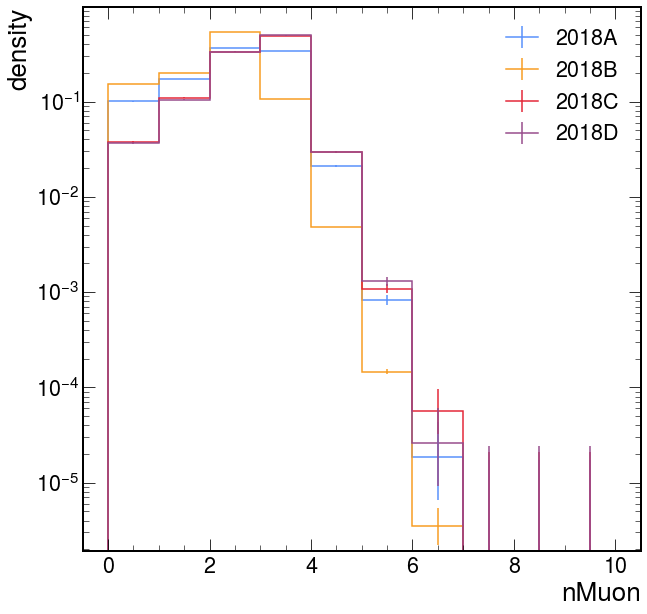

In [60]:
hist.Hist.new.Reg(10, 0, 10, name="nMuon").Double().fill(ak.num(muons_2018A)).plot(
    label="2018A", density=True
)
hist.Hist.new.Reg(10, 0, 10, name="nMuon").Double().fill(ak.num(muons_2018B)).plot(
    label="2018B", density=True
)
hist.Hist.new.Reg(10, 0, 10, name="nMuon").Double().fill(ak.num(muons_2018C)).plot(
    label="2018C", density=True
)
hist.Hist.new.Reg(10, 0, 10, name="nMuon").Double().fill(ak.num(muons_2018D)).plot(
    label="2018D", density=True
)
plt.legend()
plt.ylabel("density")
plt.yscale("log")
plt.show()

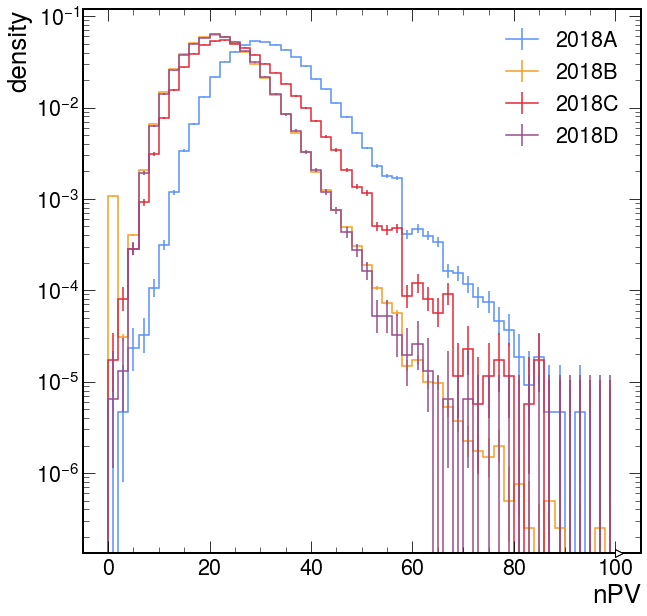

In [55]:
hist.Hist.new.Reg(50, 0, 100, name="nPV").Double().fill(events_2018A.PV.npvsGood).plot(
    label="2018A", density=True
)
hist.Hist.new.Reg(50, 0, 100, name="nPV").Double().fill(events_2018B.PV.npvsGood).plot(
    label="2018B", density=True
)
hist.Hist.new.Reg(50, 0, 100, name="nPV").Double().fill(events_2018C.PV.npvsGood).plot(
    label="2018C", density=True
)
hist.Hist.new.Reg(50, 0, 100, name="nPV").Double().fill(events_2018D.PV.npvsGood).plot(
    label="2018D", density=True
)
plt.legend()
plt.ylabel("density")
plt.yscale("log")
plt.show()

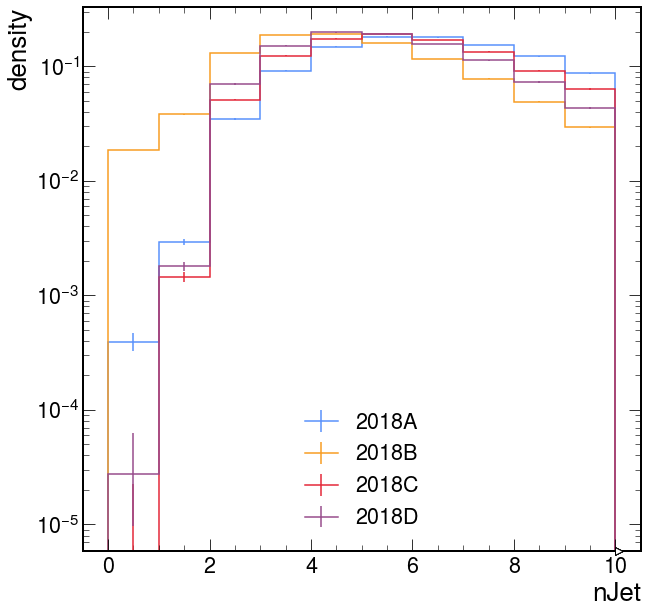

In [54]:
hist.Hist.new.Reg(10, 0, 10, name="nJet").Double().fill(ak.num(events_2018A.Jet)).plot(
    label="2018A", density=True
)
hist.Hist.new.Reg(10, 0, 10, name="nJet").Double().fill(ak.num(events_2018B.Jet)).plot(
    label="2018B", density=True
)
hist.Hist.new.Reg(10, 0, 10, name="nJet").Double().fill(ak.num(events_2018C.Jet)).plot(
    label="2018C", density=True
)
hist.Hist.new.Reg(10, 0, 10, name="nJet").Double().fill(ak.num(events_2018D.Jet)).plot(
    label="2018D", density=True
)
plt.legend()
plt.ylabel("density")
plt.yscale("log")
plt.show()

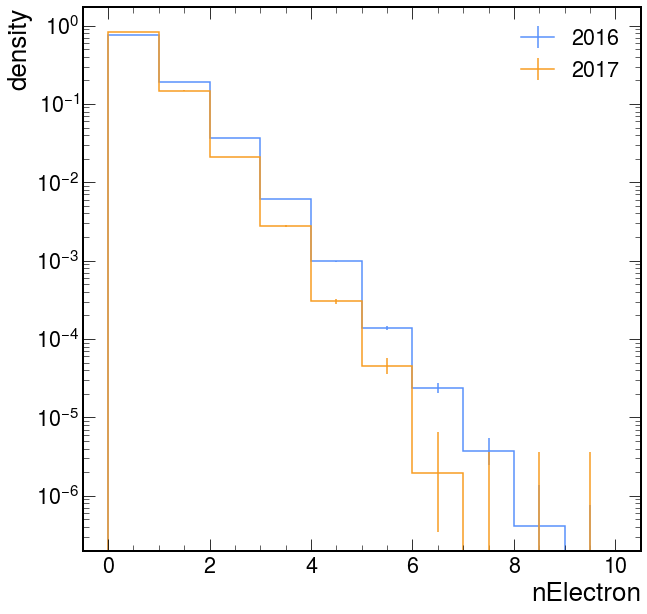

In [90]:
hist.Hist.new.Reg(10, 0, 10, name="nElectron").Double().fill(
    ak.num(events_2016.Electron)
).plot(label="2016", density=True)
hist.Hist.new.Reg(10, 0, 10, name="nElectron").Double().fill(
    ak.num(events_2017.Electron)
).plot(label="2017", density=True)
plt.legend()
plt.ylabel("density")
plt.yscale("log")
plt.show()

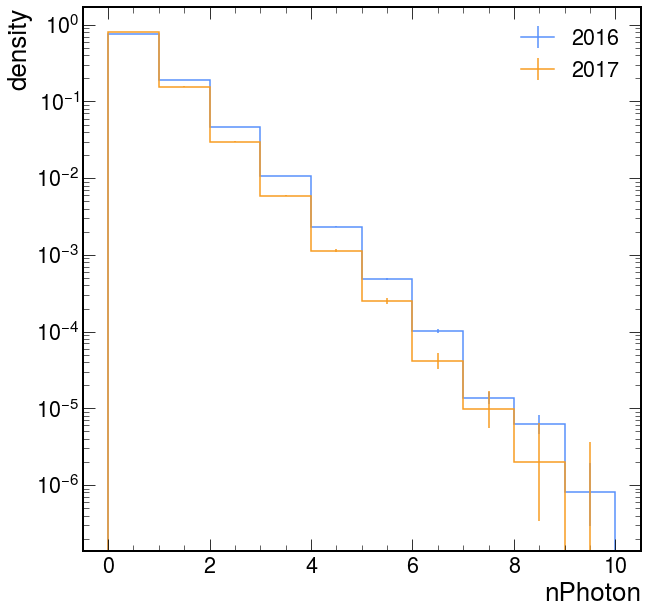

In [89]:
hist.Hist.new.Reg(10, 0, 10, name="nPhoton").Double().fill(
    ak.num(events_2016.Photon)
).plot(label="2016", density=True)
hist.Hist.new.Reg(10, 0, 10, name="nPhoton").Double().fill(
    ak.num(events_2017.Photon)
).plot(label="2017", density=True)
plt.legend()
plt.ylabel("density")
plt.yscale("log")
plt.show()

In [52]:
ak.sum(events_2017[events_2017.HLT.TripleMu_12_10_5].L1PreFiringWeight.Nom)

729.1365

In [29]:
events_2017.run

<Array [297050, 297050, ... 297050, 297050] type='10000 * uint32[parameters={"__...'>

In [36]:
(events_2017.luminosityBlock >= 734) & (events_2017.luminosityBlock <= 767)

<Array [True, True, True, ... True, True, True] type='10000 * bool'>

In [40]:
events_2016.run

<Array [278769, 278769, ... 278769, 278769] type='10000 * uint32[parameters={"__...'>

In [44]:
events_2016 = events_2016[
    (events_2016.luminosityBlock >= 75) & (events_2016.luminosityBlock <= 111)
]

In [46]:
events_2016.HLT.TripleMu_12_10_5

<Array [False, False, False, ... False, False] type='9447 * bool[parameters={"__...'>

In [55]:
(ak.sum(events_2016.HLT.TripleMu_12_10_5) / 9447) / (
    ak.sum(events_2017.HLT.TripleMu_12_10_5) / 10000
)

0.5127513504965717

In [53]:
ak.sum(events_2016[events_2016.HLT.TripleMu_12_10_5].L1PreFiringWeight.Nom)

351.89685